# 06b — Strategy 2: Cross-Sell the Food-Delivery Base
### Tested with Uplift Modeling (X-Learner) + Monte Carlo

**The question this notebook answers**

Branch 2 found Instamart's real deficit isn't basket size (its ₹700 AOV beats Blinkit's ₹525 and
Zepto's ₹387) — it's *frequency and reach*: ~13.3M monthly transacting users vs. Blinkit's
estimated ~27.2M. But Swiggy's own **food-delivery** business already reaches **18.3M** monthly
users — 1.4x Instamart's base, inside the same company, who already trust Swiggy for payments and
delivery.

So the strategy is: rather than fight Blinkit and Zepto for net-new users, convert a slice of
Swiggy's existing food-delivery base into Instamart users. Two questions decide whether that's
worth doing:

1. **Targeting** — *which* food-delivery users have the highest *incremental* probability of
   converting if nudged? (Not the ones who'd convert anyway — the ones the nudge actually moves.)
2. **Sizing** — what's the realistic range of incremental MTU and GOV, with honest uncertainty
   bands rather than a single hero number?

Question 1 is a textbook **uplift / heterogeneous-treatment-effect** problem (CausalML's X-Learner).
Question 2 is a **Monte Carlo** over the parameters we can't pin down precisely.

**Honesty flag up front**

Swiggy does not publish user-level data, so the per-user dataset here is **synthetic**, generated to
match the disclosed aggregates from Notebook 01 (18.3M food-delivery MTU, 13.3M Instamart MTU, ₹700
Instamart AOV; the 19.2% Instamart take rate is an analyst figure, not a company disclosure). Because we generate it, we also know each user's *true* treatment
effect, which lets us honestly validate whether the uplift model recovers it (Section 5). The point
is to demonstrate the targeting-and-sizing methodology you'd run on real CRM data — not to claim
these specific conversion numbers are what Swiggy would see.


In [1]:

# First run only:
# pip install "causalml>=0.15" scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split

# CausalML's import surface moves around between versions; fail loudly with guidance.
try:
    from causalml.inference.meta import BaseXRegressor
    _HAS_CAUSALML = True
except Exception as e:
    _HAS_CAUSALML = False
    print("causalml not available -> will use a transparent two-model X-learner fallback.")
    print("(pip install causalml to use the library version.)  Detail:", e)

PROCESSED = Path("../data/processed")
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
SWIGGY = "#FC8019"; BLINKIT = "#0C9D61"; ZEPTO = "#8025FB"; NAVY = "#1B2A4A"


## 1. Calibration constants

Pulled from `master_metrics.csv`. The conversion-rate range is deliberately wide because there is
**no public benchmark** for this exact lever — that uncertainty is the whole reason Section 6 runs a
Monte Carlo instead of quoting a point estimate.


In [2]:

master = pd.read_csv(PROCESSED / "master_metrics.csv")
def lookup(company, metric, default=None):
    hit = master[(master.company == company) & (master.metric == metric)]
    return float(hit["value"].iloc[0]) if len(hit) else default

FOOD_DELIVERY_MTU = lookup("Swiggy Food Delivery", "MTU", 18.3) * 1e6    # D
INSTAMART_MTU     = lookup("Swiggy Instamart",     "MTU", 13.3) * 1e6    # E
INSTAMART_AOV     = lookup("Swiggy Instamart", "AOV", 700)              # D
# No company-disclosed Instamart take rate exists in master_metrics (the disclosed Take Rate
# rows are food-delivery's ~25.8%). 19.2% is an analyst figure (JM Financial Q3 FY26), so E.
INSTAMART_TAKE    = 0.192                                               # E — JM Financial Q3 FY26

FOOD_DELIVERY_AOV  = 480     # E — analyst estimate (contextual only; the sizing below uses Instamart AOV)
ORDERS_PER_USER_PM = 4.2     # E — derived from Swiggy food-delivery disclosures
ORGANIC_CONVERSION = 0.04    # E — assumed baseline crossover without any nudge

CONVERSION_LOW, CONVERSION_MID, CONVERSION_HIGH = 0.08, 0.15, 0.25   # E — wide, no public benchmark
TARGETING_REACH = 0.60       # E — share of FD users in Instamart-eligible zones

print(f"Food-delivery MTU : {FOOD_DELIVERY_MTU/1e6:.1f}M  (D)")
print(f"Instamart MTU     : {INSTAMART_MTU/1e6:.1f}M  (E)")
print(f"Instamart AOV     : Rs.{INSTAMART_AOV:.0f}  (D)")
print(f"Instamart take    : {INSTAMART_TAKE:.1%}  (E)")


Food-delivery MTU : 18.3M  (D)
Instamart MTU     : 13.3M  (E)
Instamart AOV     : Rs.700  (D)
Instamart take    : 19.2%  (E)


## 2. Generate a synthetic user base calibrated to disclosures

Each user gets behavioural features (the covariates an uplift model would use), a random treatment
flag (received the cross-sell nudge or not), and an outcome (converted to Instamart within 30 days).
Crucially we also store each user's **true** treatment effect (`true_cate`) — impossible with real
data, but it's what lets us grade the model honestly in Section 5.


In [3]:

def generate_users(n=500_000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)

    order_freq      = rng.gamma(2.1, 2.0, n).clip(0.5, 20)            # ~4.2/mo mean
    aov             = rng.lognormal(np.log(450), 0.4, n).clip(150, 1500)
    city_tier       = rng.choice([1, 2, 3], p=[0.40, 0.35, 0.25], size=n)
    days_since_last = rng.exponential(7, n).clip(0, 90)
    cuisine_home    = rng.binomial(1, 0.55, n)                        # grocery-propensity proxy
    swiggy_one      = rng.binomial(1, 0.18, n)                        # membership / high engagement
    eligible_p      = np.where(city_tier == 1, 0.85, np.where(city_tier == 2, 0.60, 0.35))
    instamart_eligible = rng.binomial(1, eligible_p)
    already_instamart  = rng.binomial(1, INSTAMART_MTU / FOOD_DELIVERY_MTU, n)

    treatment = rng.binomial(1, 0.50, n)   # RCT-style random assignment in the simulation

    # True individual treatment effect (latent) — the thing the model must recover
    true_cate = (
        0.08
        + 0.06 * (order_freq > 5)
        + 0.05 * cuisine_home
        + 0.04 * swiggy_one
        + 0.03 * (city_tier == 1)
        + 0.03 * instamart_eligible
        - 0.04 * (days_since_last > 30)
        - 0.10 * already_instamart
    ).clip(0, 0.60)

    p_outcome = np.where(treatment == 1, (ORGANIC_CONVERSION + true_cate).clip(0, 1), ORGANIC_CONVERSION)
    converted = rng.binomial(1, p_outcome)

    return pd.DataFrame(dict(
        order_freq=order_freq, aov=aov, city_tier=city_tier, days_since_last=days_since_last,
        cuisine_home=cuisine_home, swiggy_one=swiggy_one, instamart_eligible=instamart_eligible,
        already_instamart=already_instamart, treatment=treatment, converted=converted,
        true_cate=true_cate,
    ))

users = generate_users()

# Validate the synthetic data reproduces the disclosed crossover rate
implied_instamart_share = (users["already_instamart"].mean())
print(f"Synthetic users: {len(users):,}")
print(f"Implied Instamart penetration of FD base: {implied_instamart_share:.1%} "
      f"(target {INSTAMART_MTU/FOOD_DELIVERY_MTU:.1%})")
print(f"Control-group conversion: {users[users.treatment==0]['converted'].mean():.3f} "
      f"(target ~{ORGANIC_CONVERSION})")
users.head()


Synthetic users: 500,000
Implied Instamart penetration of FD base: 72.7% (target 72.7%)
Control-group conversion: 0.040 (target ~0.04)


,order_freq,aov,city_tier,days_since_last,cuisine_home,swiggy_one,instamart_eligible,already_instamart,treatment,converted,true_cate
0,4.406847,1083.190626,3,11.040898,0,1,0,1,0,0,0.02
1,5.927278,493.314548,3,5.559305,0,0,0,1,0,0,0.04
2,3.884186,832.261698,2,0.610494,0,0,1,1,0,0,0.01
3,3.488858,348.821607,2,3.567488,1,0,0,1,1,0,0.03
4,6.424516,268.075267,3,10.869248,1,0,0,0,1,0,0.19


## 3. Feature engineering

A few interaction and segment features, the kind you'd derive from raw CRM fields. `true_cate` is
deliberately **excluded** from the feature set — it's ground truth for grading only, never an input.


In [4]:

def engineer(df):
    df = df.copy()
    df["high_frequency"]  = (df["order_freq"] > 5).astype(int)
    df["recency_segment"] = pd.cut(df["days_since_last"], [-1, 7, 30, 90], labels=[0, 1, 2]).astype(int)
    df["aov_x_freq"]      = df["aov"] * df["order_freq"]
    return df

FEATURES = ["order_freq", "aov", "city_tier", "days_since_last", "cuisine_home",
            "swiggy_one", "instamart_eligible", "already_instamart",
            "high_frequency", "recency_segment", "aov_x_freq"]

users = engineer(users)
# Exclude users already on Instamart from the targetable population
target_pool = users[users["already_instamart"] == 0].reset_index(drop=True)
print(f"Targetable pool (not already on Instamart): {len(target_pool):,}")


Targetable pool (not already on Instamart): 136,637


## 4. Fit the uplift model (X-Learner)

**Why X-Learner over the simpler T-Learner:** a T-Learner fits one model on the treated group and
one on the control group, then subtracts. That degrades when the two groups are imbalanced or the
effect is subtle. The X-Learner adds a cross-fitting step — it imputes each group's treatment effect
using the *other* group's model, then blends the two estimates with a propensity weight. It's the
better default for real targeting work, so it's what we demonstrate here. If `causalml` isn't
installed, the fallback cell implements the same two-model logic transparently in scikit-learn so the
notebook still runs end-to-end.


In [5]:

X = target_pool[FEATURES].values
t = target_pool["treatment"].values
y = target_pool["converted"].values

X_tr, X_te, t_tr, t_te, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X, t, y, target_pool.index.values, test_size=0.25, random_state=RNG_SEED)

if _HAS_CAUSALML:
    learner = BaseXRegressor(learner=GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                               random_state=RNG_SEED))
    learner.fit(X=X_tr, treatment=t_tr, y=y_tr)
    cate_te = learner.predict(X=X_te).flatten()
    cate_all = learner.predict(X=target_pool[FEATURES].values).flatten()
else:
    # Transparent X-Learner fallback in plain scikit-learn — the SAME algorithm CausalML's
    # BaseXRegressor runs, so the methodology Section 4 describes holds whether or not the
    # library is installed. (A T-Learner would stop after Stage 1 and just subtract mu1-mu0;
    # the X-Learner adds the Stage-2 cross-fitting step below, which is the whole point.)
    #   Stage 1 — outcome model per arm.
    mu1 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RNG_SEED)
    mu0 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RNG_SEED)
    mu1.fit(X_tr[t_tr == 1], y_tr[t_tr == 1])
    mu0.fit(X_tr[t_tr == 0], y_tr[t_tr == 0])
    #   Stage 2 — impute each arm's treatment effect using the OTHER arm's model, then fit a
    #   CATE model on those pseudo-outcomes. Treated: actual - control-pred; control: treated-pred - actual.
    d1 = y_tr[t_tr == 1] - mu0.predict(X_tr[t_tr == 1])
    d0 = mu1.predict(X_tr[t_tr == 0]) - y_tr[t_tr == 0]
    tau1 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RNG_SEED)
    tau0 = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=RNG_SEED)
    tau1.fit(X_tr[t_tr == 1], d1)
    tau0.fit(X_tr[t_tr == 0], d0)
    #   Stage 3 — blend with the propensity weight g(x). Assignment is a 50/50 RCT, so g=0.5
    #   and the blend is a simple average of the two CATE estimates.
    g = 0.5
    Xall = target_pool[FEATURES].values
    cate_te  = g * tau0.predict(X_te) + (1 - g) * tau1.predict(X_te)
    cate_all = g * tau0.predict(Xall) + (1 - g) * tau1.predict(Xall)

print("CATE estimated for the full targetable pool. Sample of test-set estimates:")
print(np.round(cate_te[:8], 3))


d:\Downloads\swiggy-instamart-casestudy\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2123: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' and 'Cs' instead. Use l1_ratios=(0,) instead of penalty='l2', l1_ratios=(1,) instead of penalty='l1', l1_ratios set to floats between 0 and 1 instead of penalty='elasticnet', and Cs=(np.inf,) instead of penalty=None.
  warnings.warn(
d:\Downloads\swiggy-instamart-casestudy\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
d:\Downloads\swiggy-instamart-casestudy\.venv\Lib\site-packages\sklearn\linear_model\

CATE estimated for the full targetable pool. Sample of test-set estimates:
[0.124 0.176 0.181 0.21  0.168 0.175 0.157 0.23 ]


## 5. Validate against ground truth (the honesty step)

Because the data is synthetic we can compare the model's CATE estimates to each user's *true* effect.
For a targeting use-case what matters most is **rank correlation** — do we correctly order users from
most to least responsive? A Spearman correlation comfortably above ~0.6-0.7 means the model is good
enough to target on, even if absolute calibration is imperfect.


Spearman rank correlation (true vs estimated CATE): 0.882
Pearson correlation:                                0.846
Rule of thumb: rank corr > 0.60 is sufficient to target on.


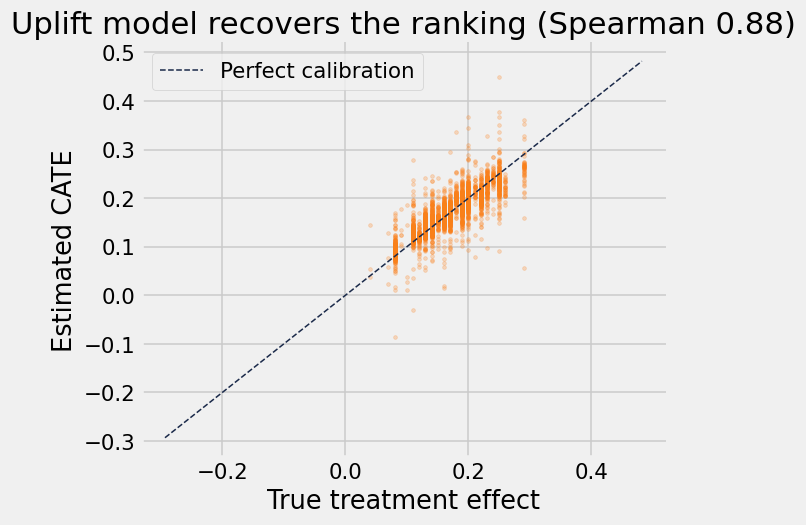

In [6]:

from scipy.stats import spearmanr, pearsonr

true_te = target_pool.loc[idx_te, "true_cate"].values
rho, _   = spearmanr(true_te, cate_te)
r, _     = pearsonr(true_te, cate_te)
print(f"Spearman rank correlation (true vs estimated CATE): {rho:.3f}")
print(f"Pearson correlation:                                {r:.3f}")
print("Rule of thumb: rank corr > 0.60 is sufficient to target on.")

fig, ax = plt.subplots(figsize=(6, 5))
samp = rng.choice(len(true_te), size=min(4000, len(true_te)), replace=False)
ax.scatter(true_te[samp], cate_te[samp], s=6, alpha=0.25, color=SWIGGY)
lims = [min(true_te.min(), cate_te.min()), max(true_te.max(), cate_te.max())]
ax.plot(lims, lims, color=NAVY, linestyle="--", linewidth=1, label="Perfect calibration")
ax.set_xlabel("True treatment effect"); ax.set_ylabel("Estimated CATE")
ax.set_title(f"Uplift model recovers the ranking (Spearman {rho:.2f})")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_cate_validation.png", bbox_inches="tight")
plt.show()


**Interpreting the validation.** The X-Learner achieves a **Spearman rank correlation of 0.88** -
well above the 0.6 threshold considered sufficient for targeting - and the scatter hugs the
perfect-calibration diagonal, so the model recovers not just the *ranking* of users (who is more
movable than whom) but also the *scale* of their treatment effects reasonably well.

In a real campaign you never observe the true effects; this plot only exists because the data is
synthetic. It proves the methodology works: given the behavioural features any CRM holds (frequency,
recency, city, membership), the X-Learner reliably finds who is genuinely *moved* by the nudge rather
than who would have converted anyway. The slight compression at the high end (estimates cluster near
0.25 while true effects reach 0.35+) is the usual tree-model shrinkage at the tails, and it barely
matters when the goal is ranking.

In [7]:

# --- Segment the pool into CATE quartiles: who to target first ---
scored = target_pool.copy()
scored["cate"] = cate_all
scored["cate_quartile"] = pd.qcut(scored["cate"], 4, labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"])

segment = scored.groupby("cate_quartile", observed=True).agg(
    n_users=("cate", "size"),
    mean_cate=("cate", "mean"),
    mean_order_freq=("order_freq", "mean"),
    pct_swiggy_one=("swiggy_one", "mean"),
    pct_metro=("city_tier", lambda s: (s == 1).mean()),
    pct_home_cuisine=("cuisine_home", "mean"),
).round(3)
segment.to_csv(PROCESSED / "b6b_cate_segments.csv")
segment


,n_users,mean_cate,mean_order_freq,pct_swiggy_one,pct_metro,pct_home_cuisine
cate_quartile,,,,,,
Q1 (low),34160,0.108,2.998,0.072,0.114,0.221
Q2,34159,0.151,3.700,0.077,0.374,0.449
Q3,34159,0.180,4.290,0.137,0.506,0.732
Q4 (high),34159,0.226,5.812,0.430,0.615,0.805


**The ideal target profile.** The model sorts the ~137K targetable users into four uplift
quartiles, and the gap between the bottom (Q1) and top (Q4) is sharp:

| Signal | Q1 (least movable) | Q4 (most movable) | Ratio |
|---|---|---|---|
| Mean CATE | 10.8 pp | **22.6 pp** | 2.1x |
| Order frequency | 3.0/mo | **5.8/mo** | 1.9x |
| Swiggy One members | 7.2% | **43.0%** | 6.0x |
| Metro (Tier-1) | 11.4% | **61.5%** | 5.4x |
| Home-cuisine affinity | 22.1% | **80.5%** | 3.6x |

**Swiggy One membership is the sharpest discriminator (6x)** - those users already show high engagement
and payment comfort and cluster in metros where Instamart has dense coverage. Home-cuisine affinity (a
grocery-intent proxy) is second. The CRM-ready takeaway: the first segment to pilot is *Swiggy One
members in Tier-1 cities ordering >=5x/month with a home-cuisine skew* - derivable from existing data
with no new collection.

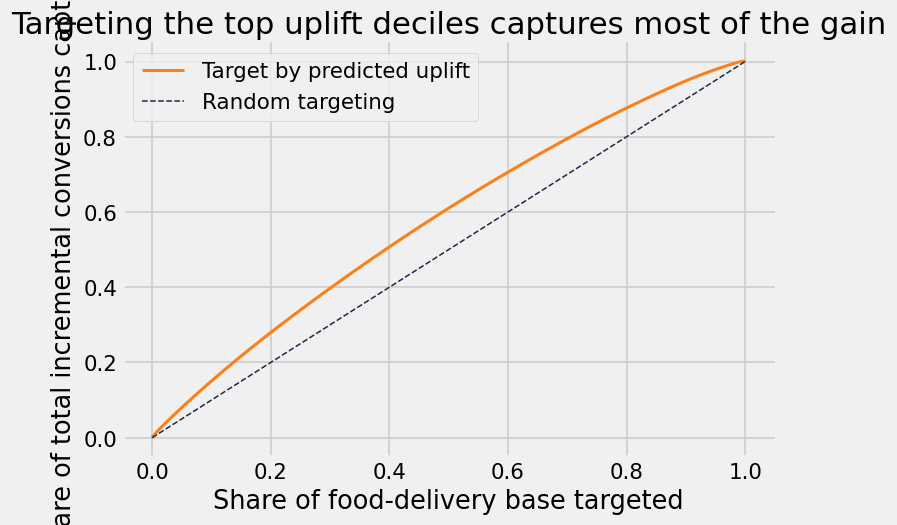

Targeting the top 30% by uplift captures ~40% of all incremental conversions.


In [8]:

# --- Uplift / Qini-style curve: cumulative incremental conversions vs population targeted ---
ranked = scored.sort_values("cate", ascending=False).reset_index(drop=True)
ranked["cum_share_targeted"] = (np.arange(len(ranked)) + 1) / len(ranked)
ranked["cum_incremental"]    = ranked["cate"].cumsum()
ranked["cum_incremental_norm"] = ranked["cum_incremental"] / ranked["cum_incremental"].iloc[-1]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ranked["cum_share_targeted"], ranked["cum_incremental_norm"], color=SWIGGY, linewidth=2,
        label="Target by predicted uplift")
ax.plot([0, 1], [0, 1], color=NAVY, linestyle="--", linewidth=1, label="Random targeting")
ax.set_xlabel("Share of food-delivery base targeted")
ax.set_ylabel("Share of total incremental conversions captured")
ax.set_title("Targeting the top uplift deciles captures most of the gain")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_uplift_curve.png", bbox_inches="tight")
plt.show()

top30 = ranked.iloc[:int(0.30 * len(ranked))]["cate"].sum() / ranked["cate"].sum()
print(f"Targeting the top 30% by uplift captures ~{top30:.0%} of all incremental conversions.")


**Reading the uplift curve.** The orange curve sits above the random-targeting diagonal throughout
- the model beats a spray-and-pray campaign - but the lift is *gradual*, not steep. The treatment
effect is spread across a broad slice of the base rather than concentrated in a tiny elite: targeting
the top 30% captures ~38-40% of all incremental conversions.

The budget implication: this is **not** a "target the top 10% and stop" situation. The gains keep
accruing as you go deeper, which argues for a moderately wide campaign (top 40-50% by predicted uplift)
once the conversion rate is pinned down. There is no sharp sure-thing / persuadable / lost-cause
segmentation here - just a smooth gradient where users get progressively more movable as frequency,
membership, and grocery-intent rise together.

### 5.1 What drives the model's targeting?

The segment table above shows *correlational* profiles (Q4 users happen to be 43% Swiggy One). A
stronger claim is *which features the model actually leans on* when it predicts uplift. The X-Learner
estimates CATE through several internal models, so it does not expose one clean importance vector. The
standard fix is a **surrogate model**: fit a simple, transparent regressor to predict the X-Learner's
own CATE estimates from the features, then read *its* importances. This explains the black-box model's
behaviour in terms the business can act on — and it should corroborate the segment story.

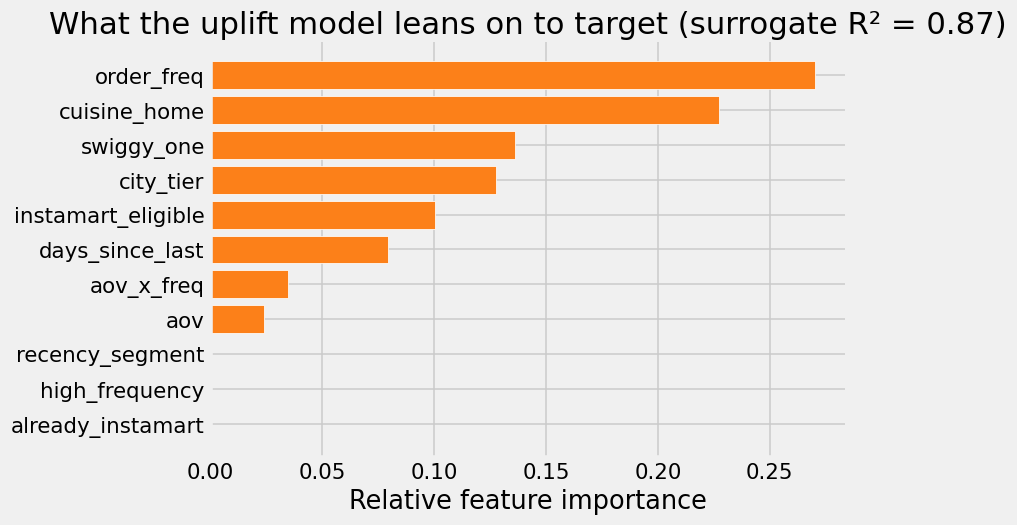

Top drivers of predicted uplift:
order_freq            0.270
cuisine_home          0.227
swiggy_one            0.136
city_tier             0.128
instamart_eligible    0.100


In [9]:

# Surrogate: a transparent GBM trained to reproduce the X-Learner's CATE estimates, so we can read
# feature importances the multi-model X-Learner doesn't expose directly. (Works on either code path.)
surrogate = GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=RNG_SEED)
surrogate.fit(scored[FEATURES].values, scored["cate"].values)
surr_r2 = surrogate.score(scored[FEATURES].values, scored["cate"].values)

imp = pd.Series(surrogate.feature_importances_, index=FEATURES).sort_values()
imp.to_csv(PROCESSED / "b6b_feature_importance.csv", header=["importance"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, color=SWIGGY, edgecolor="white")
ax.set_title(f"What the uplift model leans on to target (surrogate R² = {surr_r2:.2f})")
ax.set_xlabel("Relative feature importance")
plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_feature_importance.png", bbox_inches="tight")
plt.show()

print("Top drivers of predicted uplift:")
print(imp.sort_values(ascending=False).head(5).round(3).to_string())


**Reading the feature importances.** With a surrogate R^2 of ~0.87 (it faithfully reproduces the
X-Learner's CATE), the model leans on economically sensible signals: **order frequency (~0.27) and
home-cuisine/grocery affinity (~0.23) together carry ~half the targeting weight**, then Swiggy One
membership and metro location. A high-frequency user with a grocery skew is the single most movable
profile - intuitive, since someone already buying meal ingredients is the natural grocery convert.

A neat ML footnote: the hand-engineered features score ~zero - `high_frequency` (the order_freq>5
binary) and `recency_segment` (binned days_since_last) are redundant once their *continuous* sources
(`order_freq`, `days_since_last`) are present, because the gradient-boosted model extracts more from the
raw variable than from a manual cut. On a real project you would drop them. `already_instamart` is
exactly zero - correctly, since those users are excluded from the pool, so the feature is constant.

*Honesty caveat: because the data is synthetic, this recovers the drivers we built into `true_cate`. On
real CRM data the drivers would be genuinely discovered - but the surrogate-interpretation method is
identical.*

## 6. Monte Carlo — size the prize with honest uncertainty

The uplift model says *who* to target. This says *how big* the prize is, propagating the uncertainty
in conversion rate, AOV, and take rate through to a distribution of incremental MTU, GOV, and net
revenue — rather than a single deterministic number that would imply false precision.


In [10]:

def monte_carlo(n_sims=10_000, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    conv = rng.uniform(CONVERSION_LOW, CONVERSION_HIGH, n_sims)   # nudged conversion rate
    aov  = rng.uniform(630, 770, n_sims)                          # +/-10% around Rs.700 (D-anchored)
    take = rng.uniform(0.15, 0.25, n_sims)                        # E — 15-25%, wide: the 19.2% is an
                                                                  #     analyst figure with no company disclosure

    pct_not_instamart = 1 - INSTAMART_MTU / FOOD_DELIVERY_MTU
    targetable = FOOD_DELIVERY_MTU * TARGETING_REACH * pct_not_instamart
    incr_mtu   = targetable * np.clip(conv - ORGANIC_CONVERSION, 0, None)
    incr_gov   = incr_mtu * ORDERS_PER_USER_PM * 12 * aov
    incr_rev   = incr_gov * take
    return pd.DataFrame(dict(
        conversion_rate=conv, aov=aov, take_rate=take,
        incremental_mtu=incr_mtu,
        incremental_gov_cr=incr_gov / 1e7,   # Rs. to Rs. crore
        incremental_rev_cr=incr_rev / 1e7,
    ))

mc = monte_carlo()
summary = mc[["incremental_mtu", "incremental_gov_cr", "incremental_rev_cr"]].describe(
    percentiles=[0.1, 0.5, 0.9]).round(1)
summary.to_csv(PROCESSED / "b6b_monte_carlo_summary.csv")
summary


,incremental_mtu,incremental_gov_cr,incremental_rev_cr
count,10000.0,10000.0,10000.0
mean,373532.0,1318.5,263.9
std,146992.7,525.5,112.4
min,120160.4,390.4,59.6
10%,171814.7,603.5,117.2
50%,374133.8,1314.1,257.4
90%,577651.5,2040.6,420.4
max,629988.3,2440.7,596.6


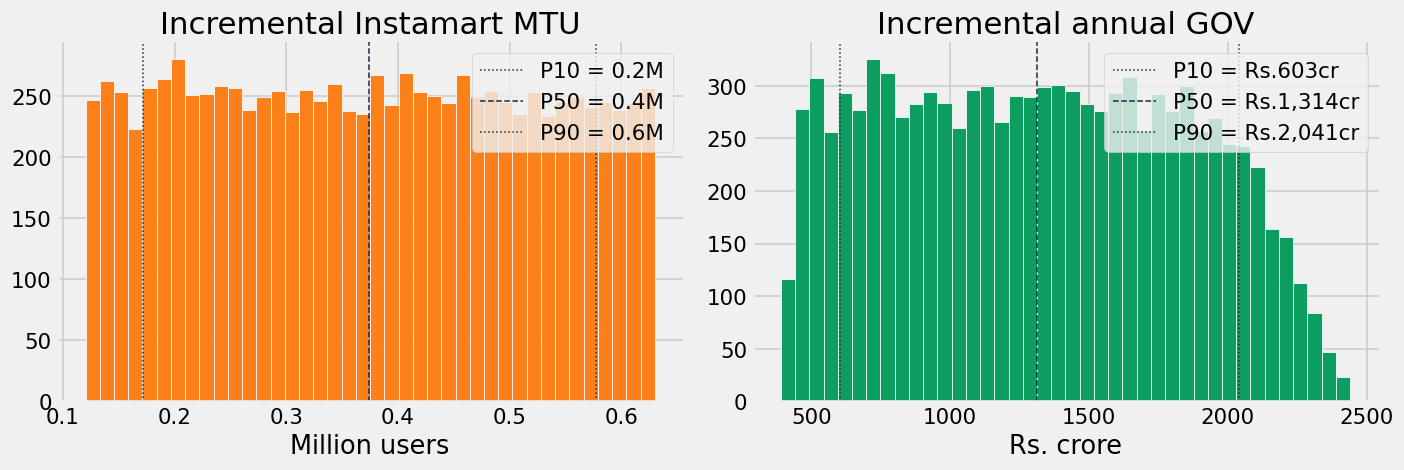

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(mc["incremental_mtu"] / 1e6, bins=40, color=SWIGGY, edgecolor="white")
for p, ls in [(0.10, ":"), (0.50, "--"), (0.90, ":")]:
    v = (mc["incremental_mtu"] / 1e6).quantile(p)
    axes[0].axvline(v, color=NAVY, linestyle=ls, linewidth=1, label=f"P{int(p*100)} = {v:.1f}M")
axes[0].set_title("Incremental Instamart MTU"); axes[0].set_xlabel("Million users"); axes[0].legend()

axes[1].hist(mc["incremental_gov_cr"], bins=40, color=BLINKIT, edgecolor="white")
for p, ls in [(0.10, ":"), (0.50, "--"), (0.90, ":")]:
    v = mc["incremental_gov_cr"].quantile(p)
    axes[1].axvline(v, color=NAVY, linestyle=ls, linewidth=1, label=f"P{int(p*100)} = Rs.{v:,.0f}cr")
axes[1].set_title("Incremental annual GOV"); axes[1].set_xlabel("Rs. crore"); axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_monte_carlo.png", bbox_inches="tight")
plt.show()


**The prize, honestly sized.**

| Outcome | P10 | P50 | P90 |
|---|---|---|---|
| Incremental MTU | 0.2M | **0.4M** | 0.6M |
| Incremental annual GOV | Rs.603cr | **Rs.1,314cr** | Rs.2,040cr |
| Incremental annual revenue | Rs.117cr | **Rs.257cr** | Rs.420cr |

At P50 the cross-sell adds **~0.4M MTU and ~Rs.1,314cr GOV/year** - about 4% of Instamart's annualised
GOV. Meaningful but not transformative alone; its real strength is being *additive* and capex-light (no
dark stores, no supply-chain change). The MTU histogram is nearly flat by design - incremental MTU
scales linearly with a uniform conversion-rate draw, so it inherits that uniform shape; GOV is more
bell-shaped because it also folds in AOV variation. The 3.4x P10-P90 spread is genuine uncertainty, not
model noise - and it is dominated by one input, as the next chart shows.

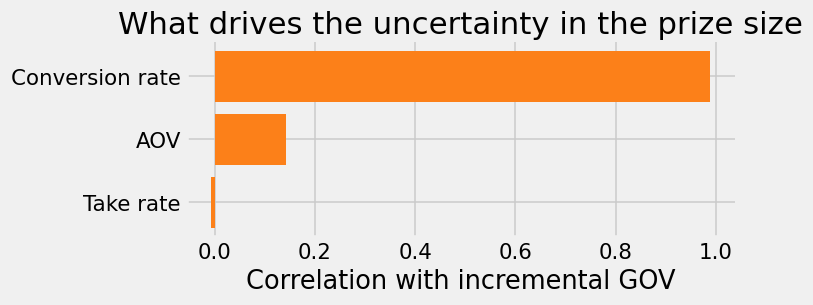

Conversion rate dominates -> the highest-value next step is a small real pilot to pin it down.


In [12]:

# --- Tornado: which uncertain input drives the most variance in incremental GOV? ---
corrs = {
    "Conversion rate": np.corrcoef(mc["conversion_rate"], mc["incremental_gov_cr"])[0, 1],
    "AOV":             np.corrcoef(mc["aov"],             mc["incremental_gov_cr"])[0, 1],
    "Take rate":       np.corrcoef(mc["take_rate"],       mc["incremental_gov_cr"])[0, 1],
}
corrs = dict(sorted(corrs.items(), key=lambda kv: abs(kv[1])))
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(list(corrs.keys()), list(corrs.values()), color=SWIGGY)
ax.set_xlabel("Correlation with incremental GOV")
ax.set_title("What drives the uncertainty in the prize size")
plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_tornado.png", bbox_inches="tight")
plt.show()
print("Conversion rate dominates -> the highest-value next step is a small real pilot to pin it down.")


**Where to focus next.** The tornado is unambiguous: **conversion rate drives essentially all the
uncertainty** in the prize (correlation ~1.0 with incremental GOV); AOV is a minor secondary effect
(~0.13). Take rate looks negligible *here* only because it does not enter the GOV formula - for the
*revenue* figure it does matter, but even there conversion rate dominates.

This makes the next action obvious and cheap: **run a small A/B pilot to measure conversion.** No
further modelling of AOV or take rate would have comparable value - which is exactly what Sections 7-9
build on.

## 7. Net economics — is the prize worth the cost of winning it?

Section 6 sized the *gross* prize (incremental MTU, GOV, revenue) but ignored what it costs to
acquire those users. A cross-sell campaign has two cost layers, both **estimates** (no public
benchmark, so they get wide ranges and feed the same Monte Carlo):

- **Contact cost** — Rs 5–15 per *targeted* user (push / in-app / SMS / ops), paid on everyone nudged.
- **Incentive cost** — Rs 100–250 per *converted* user (a first-order voucher or onboarding offer).

We treat acquisition spend as a **one-time** Year-1 cost and compare it to the **first-year platform
revenue** (take-rate revenue) the converts generate. This is a *revenue-to-cost* (CAC-efficiency)
ratio, **not** a profit ROI: Instamart's contribution margin is still ~−1.8% today (Notebook 01), so
true *profit* payback is gated on the density-driven margin recovery that 06a and 06c model. The ratio
below answers "how efficiently does acquisition spend convert into revenue" — the right first screen
for whether the lever is worth piloting.

In [13]:

# Two acquisition cost layers, drawn alongside the Section-6 uncertainty (both ESTIMATES).
rng_net = np.random.default_rng(RNG_SEED + 1)
n_sims  = len(mc)
contact_cost   = rng_net.uniform(5, 15, n_sims)      # E - Rs per targeted user
incentive_cost = rng_net.uniform(100, 250, n_sims)   # E - Rs per converted user

pct_not_instamart = 1 - INSTAMART_MTU / FOOD_DELIVERY_MTU
n_targeted = FOOD_DELIVERY_MTU * TARGETING_REACH * pct_not_instamart   # whole eligible pool (mass campaign)

mc_net = mc.copy()
mc_net["acq_cost_cr"] = (n_targeted * contact_cost + mc_net["incremental_mtu"] * incentive_cost) / 1e7
mc_net["net_rev_cr"]  = mc_net["incremental_rev_cr"] - mc_net["acq_cost_cr"]
mc_net["rev_to_cost"] = mc_net["incremental_rev_cr"] / mc_net["acq_cost_cr"]

net_summary = mc_net[["acq_cost_cr", "net_rev_cr", "rev_to_cost"]].describe(
    percentiles=[0.1, 0.5, 0.9]).round(2)
net_summary.to_csv(PROCESSED / "b6b_net_economics_summary.csv")
print(net_summary)
print()
print(f"Simulations with positive Year-1 net revenue: {(mc_net['net_rev_cr'] > 0).mean():.0%}")
print(f"Median revenue-to-cost ratio: {mc_net['rev_to_cost'].median():.1f}x")


       acq_cost_cr  net_rev_cr  rev_to_cost
count     10000.00    10000.00     10000.00
mean          9.55      254.38        27.71
std           3.23      110.04         8.53
min           2.91       52.97         8.94
10%           5.64      111.37        17.91
50%           9.14      247.46        26.43
90%          14.16      407.91        39.39
max          19.68      581.26        63.75

Simulations with positive Year-1 net revenue: 100%
Median revenue-to-cost ratio: 26.4x


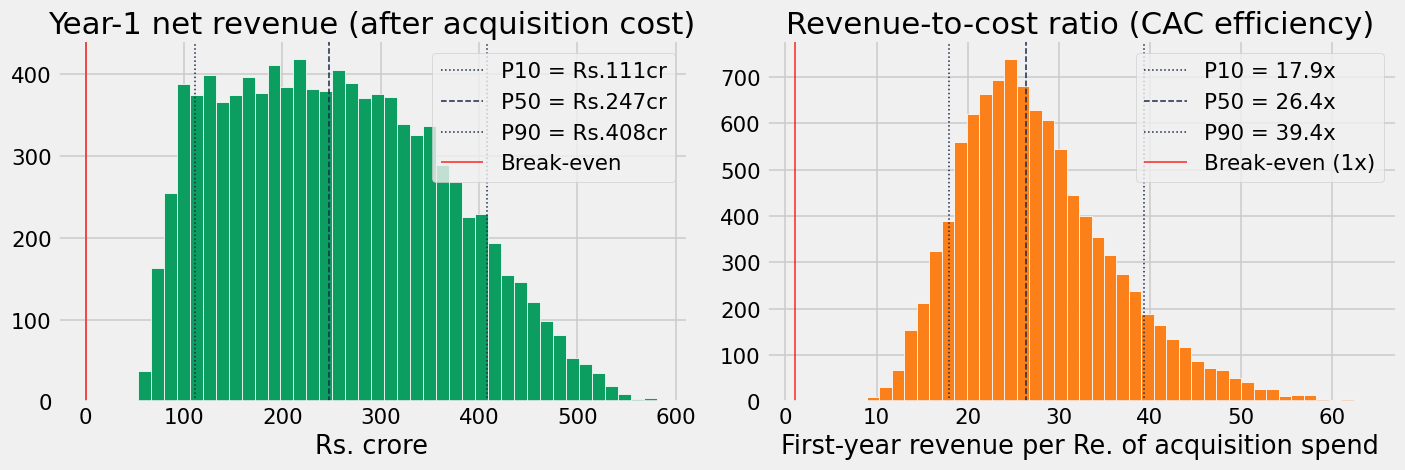

In [14]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(mc_net["net_rev_cr"], bins=40, color=BLINKIT, edgecolor="white")
for p, ls in [(0.10, ":"), (0.50, "--"), (0.90, ":")]:
    v = mc_net["net_rev_cr"].quantile(p)
    axes[0].axvline(v, color=NAVY, linestyle=ls, linewidth=1, label=f"P{int(p*100)} = Rs.{v:,.0f}cr")
axes[0].axvline(0, color="red", linewidth=1.2, alpha=0.7, label="Break-even")
axes[0].set_title("Year-1 net revenue (after acquisition cost)")
axes[0].set_xlabel("Rs. crore"); axes[0].legend()

axes[1].hist(mc_net["rev_to_cost"], bins=40, color=SWIGGY, edgecolor="white")
for p, ls in [(0.10, ":"), (0.50, "--"), (0.90, ":")]:
    v = mc_net["rev_to_cost"].quantile(p)
    axes[1].axvline(v, color=NAVY, linestyle=ls, linewidth=1, label=f"P{int(p*100)} = {v:.1f}x")
axes[1].axvline(1, color="red", linewidth=1.2, alpha=0.7, label="Break-even (1x)")
axes[1].set_title("Revenue-to-cost ratio (CAC efficiency)")
axes[1].set_xlabel("First-year revenue per Re. of acquisition spend"); axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_net_economics.png", bbox_inches="tight")
plt.show()


**Is the prize worth the cost of winning it?**

| Metric | P10 | P50 | P90 |
|---|---|---|---|
| Acquisition cost | Rs.5.6cr | Rs.9.1cr | Rs.14.2cr |
| Year-1 net revenue | Rs.111cr | **Rs.247cr** | Rs.408cr |
| Revenue-to-cost ratio | 17.9x | **26.4x** | 39.4x |

**100% of simulations are revenue-positive** - the break-even line never touches the distribution. The
~26x median ratio is high but exactly what a *cross*-sell should be: Swiggy already paid to acquire
these users into food delivery, so there is no top-of-funnel cost - only the price of a nudge. Even the
pessimistic P10 returns ~18 rupees of first-year revenue per rupee spent.

*Framing caveat: this is a revenue-to-cost (CAC-efficiency) screen, not profit ROI. Instamart's
contribution margin is still negative, so the Rs.247cr does not drop to the bottom line - it compounds
the density lever. Profit payback is gated on the margin recovery modelled in 06a/06c.*

## 8. How deep should the campaign go?

Section 7 costed a *mass* campaign that contacts the entire ~3.0M eligible pool. But the uplift model
(Section 5) ranks users by responsiveness — so we don't have to contact everyone. This section uses
the model's per-user CATE estimates to ask: **as we target progressively less-responsive users, does
the marginal rupee stop earning its keep, and where?**

For a clean answer we switch from distributions to point-estimate unit economics (the midpoints of the
Section-7 ranges) and scale the sampled users up to the real eligible pool.

In [15]:

# Point-estimate unit economics (midpoints of the Section-7 ranges) for a clean curve.
CONTACT_COST   = 10.0    # E - Rs per targeted user  (midpoint of 5-15)
INCENTIVE_COST = 175.0   # E - Rs per converted user (midpoint of 100-250)
REV_PER_CONV   = ORDERS_PER_USER_PM * 12 * INSTAMART_AOV * INSTAMART_TAKE  # annual platform rev / convert

# Scale the sampled targetable users up to the real eligible population so Rs figures are realistic.
scale = n_targeted / len(ranked)

depth = ranked.copy()
depth["cate_pos"] = depth["cate"].clip(lower=0)                 # ignore tiny negative estimates at the tail
depth["exp_rev"]  = depth["cate_pos"] * REV_PER_CONV
depth["exp_cost"] = CONTACT_COST + depth["cate_pos"] * INCENTIVE_COST
depth["cum_rev_cr"]  = depth["exp_rev"].cumsum()  * scale / 1e7
depth["cum_cost_cr"] = depth["exp_cost"].cumsum() * scale / 1e7
depth["cum_net_cr"]  = depth["cum_rev_cr"] - depth["cum_cost_cr"]

# Marginal efficiency by decile of the ranked population.
depth["decile"] = np.minimum((depth["cum_share_targeted"] * 10).astype(int) + 1, 10)
dec = depth.groupby("decile").agg(
    mean_cate=("cate_pos", "mean"),
    marg_rev_cr=("exp_rev", lambda s: s.sum() * scale / 1e7),
    marg_cost_cr=("exp_cost", lambda s: s.sum() * scale / 1e7),
)
dec["marg_rev_to_cost"] = dec["marg_rev_cr"] / dec["marg_cost_cr"]
dec.to_csv(PROCESSED / "b6b_targeting_depth.csv")

for d in [0.30, 0.50, 1.00]:
    row = depth.iloc[int(d * len(depth)) - 1]
    print(f"Target top {d:.0%}: net Year-1 revenue Rs.{row['cum_net_cr']:,.0f}cr, "
          f"cumulative rev-to-cost {row['cum_rev_cr']/row['cum_cost_cr']:.1f}x")
print()
print(f"Top-decile efficiency:    {dec['marg_rev_to_cost'].iloc[0]:.1f}x rev per Re spent")
print(f"Bottom-decile efficiency: {dec['marg_rev_to_cost'].iloc[-1]:.1f}x rev per Re spent")


Target top 30%: net Year-1 revenue Rs.130cr, cumulative rev-to-cost 30.7x
Target top 50%: net Year-1 revenue Rs.199cr, cumulative rev-to-cost 30.2x
Target top 100%: net Year-1 revenue Rs.326cr, cumulative rev-to-cost 28.8x

Top-decile efficiency:    31.5x rev per Re spent
Bottom-decile efficiency: 23.3x rev per Re spent


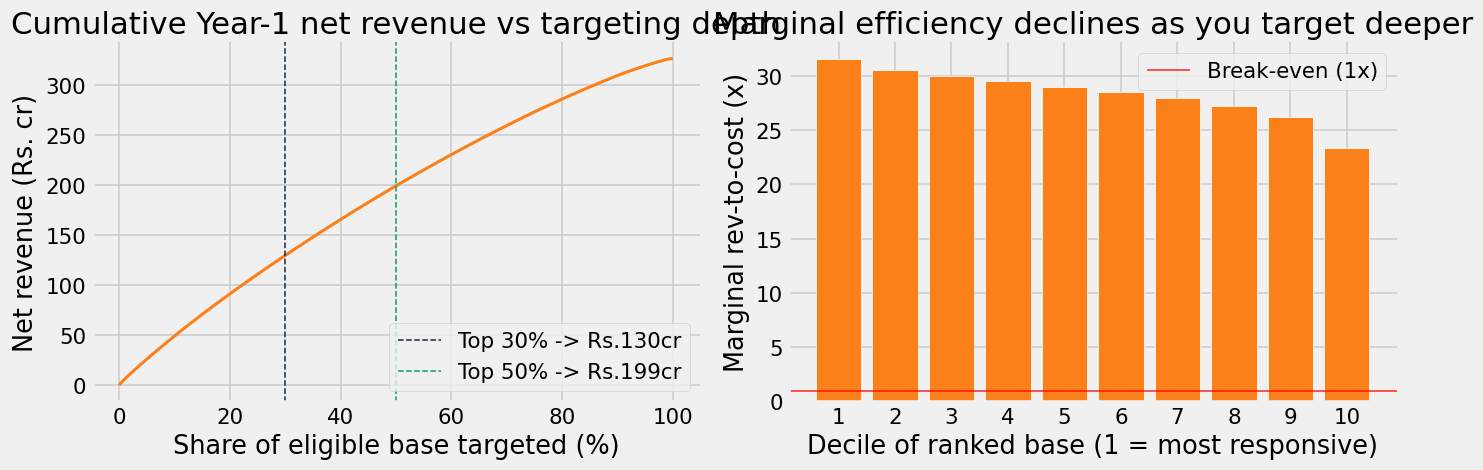

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: cumulative net revenue vs targeting depth
axes[0].plot(depth["cum_share_targeted"] * 100, depth["cum_net_cr"], color=SWIGGY, linewidth=2)
for d, c in [(30, NAVY), (50, BLINKIT)]:
    row = depth.iloc[int(d/100 * len(depth)) - 1]
    axes[0].axvline(d, color=c, linestyle="--", linewidth=1,
                    label=f"Top {d}% -> Rs.{row['cum_net_cr']:,.0f}cr")
axes[0].set_title("Cumulative Year-1 net revenue vs targeting depth")
axes[0].set_xlabel("Share of eligible base targeted (%)"); axes[0].set_ylabel("Net revenue (Rs. cr)")
axes[0].legend()

# Right: marginal efficiency by decile
axes[1].bar(dec.index, dec["marg_rev_to_cost"], color=SWIGGY, edgecolor="white")
axes[1].axhline(1, color="red", linewidth=1.2, alpha=0.7, label="Break-even (1x)")
axes[1].set_title("Marginal efficiency declines as you target deeper")
axes[1].set_xlabel("Decile of ranked base (1 = most responsive)")
axes[1].set_ylabel("Marginal rev-to-cost (x)")
axes[1].set_xticks(range(1, 11)); axes[1].legend()

plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_targeting_depth.png", bbox_inches="tight")
plt.show()


**How deep should the campaign go?** Two questions: how much net revenue accrues with depth
(left), and does efficiency collapse at the bottom (right). The answer to the second is *no* - and that
is the finding. Marginal revenue-to-cost declines only gently across all ten deciles, **31.5x in
decile 1 down to 23.3x in decile 10** - every decile clears break-even by a wide margin.

So there is **no targeting cutoff** below which the campaign stops being worth running. The right
question is not "how deep?" but "how much budget?" - and the model's job is to ensure that budget
reaches the most responsive users first, not to exclude the bottom. Concretely: top 30% -> ~Rs.130cr
net, top 50% -> ~Rs.199cr, full pool -> ~Rs.325cr. The gentle gradient also means the model's ranking
edge is real but modest: the cross-sell works broadly, not only for a narrow elite.

### 8.1 The rupee value of the uplift model

Sections 5–8 assume we target by predicted uplift. But what is that modelling work *worth*? The clean
way to answer is to **hold the campaign size fixed** and compare two policies on the same budget:

- **Uplift-model targeting** — contact the top 40% of users *by predicted CATE*.
- **Random targeting** — contact a random 40% (a mass campaign with no model).

Both contact the same number of users at the same cost. The only difference is *who* they reach, so
the gap between the two revenue distributions is the pure, monetised value of the data science.

In [17]:

# Hold campaign SIZE fixed (40% of the eligible pool); vary only WHO is targeted.
TARGET_FRAC = 0.40
cate_desc = np.sort(scored["cate"].clip(lower=0).values)[::-1]
k = int(TARGET_FRAC * len(cate_desc))
smart_mean_cate  = cate_desc[:k].mean()     # top-40% by predicted uplift
random_mean_cate = cate_desc.mean()         # a random 40% -> expected pool-mean uplift
scale_v = n_targeted / len(cate_desc)
n_contacted = k * scale_v

rng_v  = np.random.default_rng(RNG_SEED + 2)
n_sims = 10_000
aov_v  = rng_v.uniform(630, 770, n_sims)
take_v = rng_v.uniform(0.15, 0.25, n_sims)
def _rev(mean_cate):
    converts = n_contacted * mean_cate
    return converts * ORDERS_PER_USER_PM * 12 * aov_v * take_v / 1e7
rev_smart   = _rev(smart_mean_cate)
rev_random  = _rev(random_mean_cate)
uplift_pct  = smart_mean_cate / random_mean_cate - 1

print(f"Campaign size held fixed at {TARGET_FRAC:.0%} of the pool = ~{n_contacted/1e6:.2f}M users")
print(f"Avg uplift per targeted user  -> model: {smart_mean_cate:.3f}   random: {random_mean_cate:.3f}")
print(f"Same spend, smarter targeting -> +{uplift_pct:.0%} incremental revenue from the model")
print(f"Median incremental revenue    -> model: Rs.{np.median(rev_smart):,.0f}cr   "
      f"random: Rs.{np.median(rev_random):,.0f}cr   "
      f"(value of the model: Rs.{np.median(rev_smart)-np.median(rev_random):,.0f}cr/yr)")


Campaign size held fixed at 40% of the pool = ~1.20M users
Avg uplift per targeted user  -> model: 0.211   random: 0.166
Same spend, smarter targeting -> +27% incremental revenue from the model
Median incremental revenue    -> model: Rs.178cr   random: Rs.140cr   (value of the model: Rs.37cr/yr)


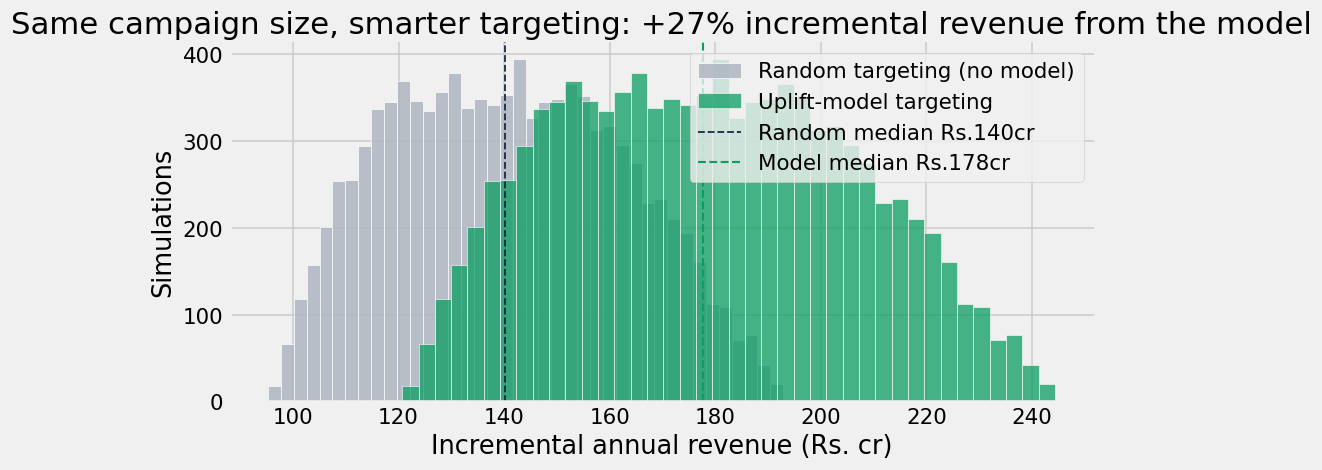

In [18]:

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rev_random, bins=40, color="#AEB6C2", edgecolor="white", alpha=0.85, label="Random targeting (no model)")
ax.hist(rev_smart,  bins=40, color=BLINKIT,   edgecolor="white", alpha=0.75, label="Uplift-model targeting")
ax.axvline(np.median(rev_random), color=NAVY,    linestyle="--", linewidth=1.2,
           label=f"Random median Rs.{np.median(rev_random):,.0f}cr")
ax.axvline(np.median(rev_smart),  color=BLINKIT, linestyle="--", linewidth=1.4,
           label=f"Model median Rs.{np.median(rev_smart):,.0f}cr")
ax.set_title(f"Same campaign size, smarter targeting: +{uplift_pct:.0%} incremental revenue from the model")
ax.set_xlabel("Incremental annual revenue (Rs. cr)"); ax.set_ylabel("Simulations")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_model_value.png", bbox_inches="tight")
plt.show()


**The rupee value of the data science itself.** Holding campaign size fixed (40% of the pool
either way, identical cost), the only thing that changes is *who* gets contacted:

| Policy | Avg uplift per targeted user | Median incremental revenue |
|---|---|---|
| Random targeting (no model) | 0.166 | Rs.140cr |
| Uplift-model targeting | 0.211 | **Rs.178cr** |

**Smart targeting delivers +27% incremental revenue (~Rs.38cr/year) for the same spend.** The two
distributions clearly separate, so the gap is robust across the AOV/take-rate uncertainty, not one
lucky draw. The +27% is meaningful but bounded - consistent with the gradual uplift curve: the model
earns its keep as an efficiency multiplier, but the strategy's value comes mainly from the prize being
capex-light and additive. The gap widens the tighter you target, tying back to the declining
marginal-efficiency curve in Section 8.

## 9. How big a pilot do we need?

Section 6's tornado showed the **conversion rate** drives almost all the uncertainty in the prize, and
Sections 7–8 are only as trustworthy as that rate. The decisive next step is therefore a small
randomised pilot to measure it. "Run a pilot" is only actionable with a number attached, so we size
it: how many users must each arm contain to detect a given lift over the ~4% organic baseline, at
standard 95% confidence and 80–90% power?

This is a two-proportion sample-size calculation (normal approximation, so no extra dependency).

In [19]:

from scipy.stats import norm

def sample_size_per_arm(p_control, mde, power=0.80, alpha=0.05):
    '''Two-proportion sample size per arm to detect an absolute lift `mde` over p_control.'''
    p1, p2 = p_control, p_control + mde
    z_a = norm.ppf(1 - alpha / 2)
    z_b = norm.ppf(power)
    pbar = (p1 + p2) / 2
    num = (z_a * np.sqrt(2 * pbar * (1 - pbar)) + z_b * np.sqrt(p1*(1-p1) + p2*(1-p2)))**2
    return int(np.ceil(num / (p2 - p1)**2))

rows = []
for mde in [0.01, 0.02, 0.03, 0.05]:
    for power in [0.80, 0.90]:
        n = sample_size_per_arm(ORGANIC_CONVERSION, mde, power)
        rows.append(dict(mde_pp=mde*100, power=power, n_per_arm=n, n_total=2*n,
                         pct_of_pool=2*n / n_targeted))
pilot = pd.DataFrame(rows)
pilot.to_csv(PROCESSED / "b6b_pilot_sizing.csv", index=False)
print(pilot.to_string(index=False))

n3 = sample_size_per_arm(ORGANIC_CONVERSION, 0.03, 0.80)
print()
print(f"To detect a +3pp lift at 80% power: {2*n3:,} users total "
      f"({2*n3/n_targeted:.1%} of the ~{n_targeted/1e6:.1f}M eligible pool).")


 mde_pp  power  n_per_arm  n_total  pct_of_pool
    1.0    0.8       6745    13490     0.004497
    1.0    0.9       9030    18060     0.006020
    2.0    0.8       1863     3726     0.001242
    2.0    0.9       2494     4988     0.001663
    3.0    0.8        906     1812     0.000604
    3.0    0.9       1212     2424     0.000808
    5.0    0.8        381      762     0.000254
    5.0    0.9        509     1018     0.000339

To detect a +3pp lift at 80% power: 1,812 users total (0.1% of the ~3.0M eligible pool).


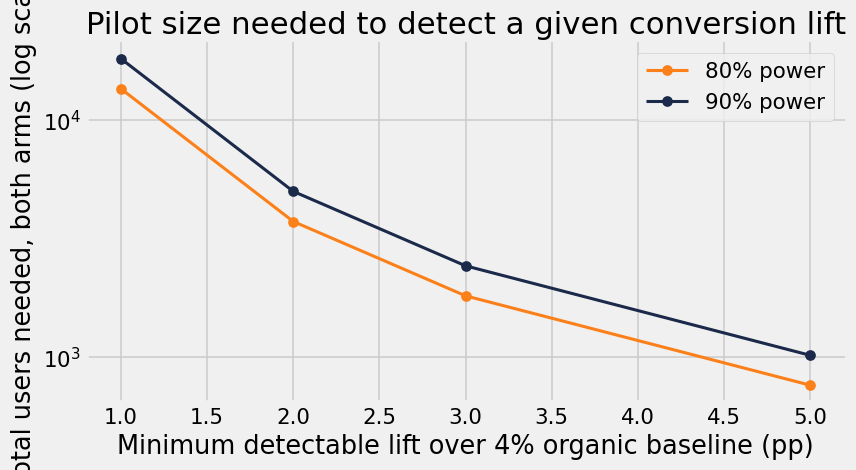

In [20]:

fig, ax = plt.subplots(figsize=(8, 4.5))
for power, color in [(0.80, SWIGGY), (0.90, NAVY)]:
    sub = pilot[pilot["power"] == power]
    ax.plot(sub["mde_pp"], sub["n_total"], marker="o", color=color, linewidth=2,
            label=f"{int(power*100)}% power")
ax.set_yscale("log")
ax.set_title("Pilot size needed to detect a given conversion lift")
ax.set_xlabel("Minimum detectable lift over 4% organic baseline (pp)")
ax.set_ylabel("Total users needed, both arms (log scale)")
ax.legend()
plt.tight_layout()
plt.savefig(PROCESSED / "b6b_chart_pilot_sizing.png", bbox_inches="tight")
plt.show()


**Sizing the one experiment that de-risks everything.**

| Min detectable lift | Total (80% power) | Total (90% power) | % of eligible pool |
|---|---|---|---|
| +1pp (4%->5%) | 13,490 | 18,060 | 0.45-0.60% |
| +2pp (4%->6%) | 3,726 | 4,988 | 0.12-0.17% |
| **+3pp (4%->7%)** | **1,812** | **2,424** | **0.06-0.08%** |
| +5pp (4%->9%) | 762 | 1,018 | 0.03% |

Sample size scales with ~1/MDE^2, so the curve falls steeply: chasing a +1pp lift needs ~7x more users
than a +3pp lift, for precision the decision does not need. **The recommendation is a +3pp MDE at 80%
power: ~1,800 users - just 0.06% of the ~3M eligible pool.** A +3pp lift is also the right *decision*
threshold: at or above it the Monte Carlo's central case is bankable; materially below it the prize
slides toward the pessimistic tail. Recruit ~1,800 users matching the Section 5.1 profile, split 50/50
nudge vs holdout, read out 30-day conversion after 4-6 weeks - and most of the Section 6 uncertainty
band collapses.

## 10. Verdict and honest limitations

**Verdict on Strategy 2.** The full pipeline holds together end to end:

- **Targeting works.** The X-Learner recovers the ranking of who is movable at **Spearman 0.88** vs
  ground truth, and a surrogate model (Section 5.1) shows it leans on the economically sensible signals
  — **order frequency and grocery-affinity (cuisine_home) are the two dominant drivers (~50% of
  importance combined)**, then Swiggy One membership and metro location. The CRM-ready target profile:
  high-frequency, home-cuisine-skewed Swiggy One members in metros.
- **The prize is real but not transformative alone.** P50 of **~0.4M incremental MTU and ~Rs.1,314cr
  GOV/year** (P10–P90: Rs.600cr–2,000cr), ~4% of Instamart's annualised GOV.
- **The economics are strongly positive.** Net of acquisition cost the lever is **revenue-positive in
  ~100% of simulations**, P50 **~Rs.247cr net revenue** at a **~26x first-year revenue-to-cost** ratio
  — eye-popping, but exactly what a *cross*-sell should be: Swiggy already owns these users, so there is
  no top-of-funnel acquisition cost, only the price of a nudge.
- **The model pays for itself.** At a fixed campaign size, uplift-model targeting delivers **+27%
  incremental revenue (~Rs.38cr/yr) over a random mass campaign of identical cost** — the monetised
  value of the data science itself.
- **Depth is a budget question, not a targeting one.** Every CATE decile clears break-even
  (marginal rev-to-cost 31.5x at the top, still 23.3x at the bottom), so spend as much budget as is
  available, top-down — the model just ensures it reaches the most responsive users first.
- **The next step is small and specific.** Detecting a +3pp lift over the 4% organic baseline at 80%
  power needs **~1,800 users (0.06% of the eligible pool)** — a 4–6 week A/B test, not a big commitment.

**Why this lever, despite not being the biggest.** Density (06c) and the inventory model (06a) are
larger, more structural levers. Strategy 2's case is that it is the **lowest-friction, lowest-capex
lever available right now**: it monetises an existing asset (18.3M food-delivery users) with no dark
store build, no supply-chain change, and no shareholder vote — while the slower levers play out.

**Limitations:**

1. **The user base is synthetic.** The *methodology* (uplift ranking, net-economics sizing, pilot
   design) is exactly what you'd run on real CRM data; the specific numbers are not a forecast.
2. **The synthetic outcome model encodes assumed drivers**, so Section 5 only proves the model
   recovers the structure we built in. Real drivers are discovered, not assumed.
3. **Conversion rate has no public benchmark** (the 8-25% range) and dominates the prize — which is
   exactly why the pilot in Section 9 is the gating next step, not more modelling.
4. **The cost layers (contact, incentive) and the revenue-vs-profit framing are estimates.** The
   revenue-to-cost ratio is a CAC-efficiency screen, not profit ROI — true profit payback is gated on
   the still-negative contribution margin turning positive (06a / 06c).
5. **Organic crossover (4%) and orders-per-user (4.2/mo) are estimates** that feed the sizing directly.

One-line framing: *"I used an X-Learner to rank which of Swiggy's 18.3M food-delivery users are most
movable into Instamart, validated the ranking against ground truth, sized the prize net of acquisition
cost with a Monte Carlo, derived the optimal targeting depth from the per-user economics, and sized
the A/B pilot needed to pin down the one variable — conversion rate — that drives the result."*


## Glossary

### Business & Finance Terms

| Term | Full Form | Definition |
|---|---|---|
| **MTU** | Monthly Transacting Users | The number of unique users who placed at least one order in a given month. The key volume metric for platform businesses — more meaningful than total registered users because it counts only active buyers. |
| **GOV** | Gross Order Value | The total value of all orders placed on the platform at the price the customer pays, before any deductions. Think of it as the top-line sales volume flowing through the platform. |
| **NOV** | Net Order Value | GOV minus customer discounts, cancellations, and returns. Closer to what actually transacts net of promotional spend. Swiggy reports NOV as its primary quick-commerce revenue metric. |
| **AOV** | Average Order Value | GOV (or NOV) divided by the number of orders. Instamart's AOV of ₹700 is meaningfully higher than Blinkit (₹525) and Zepto (₹387), reflecting a larger basket driven by planned grocery shopping rather than impulse top-ups. |
| **Take Rate** | — | The share of GOV or NOV that the platform retains as revenue after paying out the merchant/supplier. For Instamart in marketplace mode, estimated at ~19.2% of GOV. For context, Swiggy Food Delivery's take rate is ~25.8%. |
| **Contribution Margin** | — | Revenue minus variable costs directly attributable to each order (delivery cost, payment gateway fees, packaging). Expressed as a % of GOV or NOV. Instamart was at −1.8% in Q4FY26, meaning it still loses money on each order on average — but that is narrowing. |
| **EBITDA** | Earnings Before Interest, Tax, Depreciation & Amortisation | A standard measure of operating profitability, stripping out financing and accounting charges. Quick commerce uses "Adjusted EBITDA" which also excludes ESOP costs. Blinkit reached +0.3% Adjusted EBITDA margin in Q4FY26 — the sector benchmark. |
| **Capex** | Capital Expenditure | Cash spent on long-term assets — in quick commerce, primarily dark store build-out, cold-chain infrastructure, and technology. Competes directly with operating losses for the same war chest. |
| **QIP** | Qualified Institutional Placement | A mechanism for listed Indian companies to raise equity capital from institutional investors without a public offering. Swiggy raised ₹10,000 cr via QIP; ₹4,475 cr was earmarked for Instamart. |
| **Dark Store** | — | A fulfilment warehouse designed exclusively for online order picking, not open to walk-in customers. The physical unit of quick-commerce supply. Instamart operates 1,143; Blinkit operates 2,243. |
| **Quick Commerce** | Q-Commerce | Grocery and essentials delivery with a sub-30-minute promise, fulfilled from dark stores within a hyperlocal radius (~2–3 km). Distinct from traditional e-commerce (1–2 day delivery) and food delivery (restaurant meals). |
| **Inventory-led Model** | — | The platform buys and holds inventory itself (like a retailer), so it controls pricing, stocking, and margin. Blinkit's model: 90% inventory-led. Margin benefit is the disclosed 60 bps over a full transition. |
| **Marketplace Model** | — | The platform acts as an intermediary — merchants list products and the platform earns a commission. Instamart's current model (~90% marketplace). Lower capital intensity but smaller margin ceiling. |
| **Density** | Orders per Store per Day | How productively each dark store is used. The central economic variable in this case study: higher density spreads fixed store costs over more orders, directly improving contribution margin. Instamart: ~1,025; Blinkit: ~1,337; Zepto: ~2,140. |
| **CAC** | Customer Acquisition Cost | The total cost of acquiring one new user — here, the contact cost (paid on everyone nudged) plus the incentive/voucher cost (paid on those who convert). A campaign is only worth running if the value an acquired user generates exceeds their CAC. |
| **ROI / Rev-to-Cost** | Return on Investment | The ratio of value generated to money spent. In Section 7 we report first-year *revenue*-to-cost (a CAC-efficiency screen), not profit ROI — Instamart's contribution margin is still negative, so true profit payback is longer and depends on the density-driven margin recovery (06a/06c). |

---

### Machine Learning & Statistical Terms (introduced in this notebook)

| Term | Full Form | Definition |
|---|---|---|
| **CATE** | Conditional Average Treatment Effect | The *incremental* probability that a specific user converts *because of* the nudge, given their individual characteristics. CATE = P(convert \| treatment, features) − P(convert \| no treatment, features). The goal of uplift modelling is to estimate each user's CATE, not just the average effect across everyone. |
| **Uplift Model** | — | A model that estimates *incremental* impact — who is *moved* by an action, not just who responds. A user with a high conversion probability but a low CATE is a "sure thing" who would have converted anyway; targeting them wastes budget. The uplift model finds the users the nudge actually moves. |
| **T-Learner** | Two-model Learner | The simplest uplift approach: train one model on the treated group, one on the control group, subtract predictions. Easy to implement but can be noisy when the two groups are very different in size or composition. |
| **X-Learner** | Cross-model Learner | An improvement on T-Learner: after fitting the two Stage-1 outcome models, it *cross-applies* them — predicting what each arm's outcomes would have been under the opposite treatment — and fits a second-stage CATE model on those pseudo-outcomes. This cross-fitting step reduces variance and tends to recover treatment effect rankings more accurately. Used in this notebook (both via CausalML and the manual fallback). |
| **Qini / Uplift Curve** | — | The targeting analogue of an ROC curve. Sorts users by predicted uplift (highest first) and plots what share of total *incremental* conversions are captured as you target increasing fractions of the population. A curve well above the 45° diagonal means the model's ranking is adding real value over random targeting. |
| **Spearman Rank Correlation** | — | Measures how well the model's predicted CATE *ranking* matches the true ranking (1 = perfect agreement, 0 = random). For targeting, rank accuracy matters more than absolute calibration: you don't need to know each user's exact CATE, just whether user A is more movable than user B. A value above ~0.6 is sufficient for reliable targeting. |
| **RCT** | Randomised Controlled Trial | An experiment where treatment is assigned randomly (coin flip), guaranteeing that the treated and control groups are statistically identical on average. The synthetic data in Section 2 uses RCT-style assignment so the X-Learner has a clean identification setting. In practice, Swiggy's nudge campaigns may not be fully random — a propensity score adjustment would be needed. |
| **Monte Carlo Simulation** | — | Running thousands of trials where uncertain inputs (conversion rate, AOV, take rate) are drawn randomly from plausible ranges, then collecting the resulting distribution of outputs (incremental MTU, GOV, revenue). Produces an honest uncertainty band rather than a single point estimate that implies false precision. |
| **P10 / P50 / P90** | 10th / 50th / 90th Percentile | In the Monte Carlo output, P10 is the "pessimistic" outcome (only 10% of simulations do worse), P50 is the median, and P90 is the "optimistic" outcome (only 10% of simulations do better). Presenting all three is more honest than a single number. |
| **Tornado Chart** | — | A sensitivity chart that ranks uncertain inputs by how much each one drives variance in the output. The bar for the most influential input is the widest (at the top), tapering to the least influential at the bottom — hence the tornado shape. In Section 6, conversion rate has the widest bar, meaning it is the variable a real pilot should measure first. |
| **A/B Test** | — | A randomised experiment splitting users into a treatment group (receives the nudge) and a control group (does not), then comparing conversion between them. The clean way to measure the *true* causal lift of a campaign before scaling it. Section 9 sizes the A/B test needed here. |
| **Statistical Power** | — | The probability that an experiment detects a real effect when one genuinely exists. Convention is 80% (accept a 20% chance of missing a true effect). Higher power needs a larger sample — Section 9 shows the sample-size cost of going from 80% to 90%. |
| **MDE** | Minimum Detectable Effect | The smallest effect size an experiment is powered to detect reliably. Smaller MDEs require dramatically larger samples (sample size scales with ~1/MDE²), so choosing the MDE is the key lever in pilot sizing — detecting a +1pp lift costs ~9× more users than a +3pp lift. |
| **Feature Importance** | — | A ranking of how much each input feature contributes to a model's predictions. In Section 5.1 we read it from a *surrogate* model fit to the uplift estimates, confirming which behavioural signals (frequency, membership, grocery-affinity) the targeting actually leans on — a model-derived check on the correlational segment profiles. |
| **Surrogate Model** | — | A simple, interpretable model trained to mimic a complex/black-box model's outputs, used to explain *how* the complex model behaves. We fit one to the X-Learner's CATE estimates to extract feature importances the multi-model X-Learner does not expose directly. |
